# Phase 4: Data Collection and Exploratory Data Analysis
**CS 5304 | Spring 2026**

**Team Members:**
- Hongyiming Cui
- Xiaohui Zang
- Jiawei Wang
- George Zhu

## GitHub Repository Link: 

https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project

***
## Introduction

This project investigates the relationship between socioeconomic factors and health outcomes across U.S. states, with a focus on how median household income influences chronic disease mortality. Building on the dataset constructed in earlier phases, we analyze state-level data for 2024 to examine whether a socioeconomic gradient exists in health outcomes and to what extent this relationship is mediated by behavioral factors such as smoking, obesity, and physical activity.

We begin by briefly describing the dataset and data preparation process, followed by preregistered hypotheses that guide our analysis. We then conduct exploratory data analysis to identify key patterns and relationships, and implement regression models to evaluate the statistical significance of income and other covariates in explaining variation in mortality outcomes. Finally, we summarize our findings, discuss limitations, and highlight implications for understanding health disparities.

Overall, this analysis aims to provide a data-driven perspective on the role of socioeconomic conditions in shaping population health outcomes.

***
## Research Question

**Primary question:** To what extent does the socioeconomic gradient — measured by state-level median household income — explain variation in chronic disease mortality (heart disease and diabetes) across U.S. states in 2024?

**Secondary question:** How much of the income–mortality relationship is mediated by health behaviors (obesity, smoking, physical inactivity), versus income acting as an independent predictor?

We focus on state-level cross-sectional data for 2024 because our datasets lack monthly granularity, making a cross-sectional design more appropriate than a short panel. The unit of analysis is the U.S. state (+ D.C.), giving us 51 observations.

***
## Data Description

We construct a **cross-sectional dataset of U.S. states (50 states + D.C., n = 51) for 2024** to study how socioeconomic factors relate to chronic disease outcomes. The dataset combines publicly available sources and is merged into a single file:  `final_state_health_dataset_2024.csv`

### Data Sources

We use two primary data sources:

- **U.S. Census Bureau (ACS 2024 1-Year Estimates)**  

  - Provides median household income, our main socioeconomic variable.

- **Kaiser Family Foundation (KFF) State Health Facts (2024)**  

  - Provides state-level health outcomes and behavioral risk factors.

Raw data and full documentation are available at:  

- **GitHub repository:** [Phase 2 notebook](https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project/blob/main/Phase_2.ipynb). 

- **Raw datasets:** [Google Drive Folder (All Datasets)](https://drive.google.com/drive/folders/1NwQ0BWzhuBbGxfQMNevCeiuQg0POtBLS?usp=sharing)

### Unit of Analysis

- **Observation level:** U.S. state (including D.C.)  

- **Sample size:** 51  

- **Design:** Cross-sectional (2024 only)

A cross-sectional design is appropriate because the datasets do not provide consistent multi-period panel data at the state level.

### Key Variables

We focus on variables that capture the **socioeconomic gradient, health outcomes, and behavioral mechanisms**:

#### 1. Independent Variable (Socioeconomic)

- **Median_Income**: Median household income (USD)

#### 2. Dependent Variables (Health Outcomes)

- **Heart_Disease**: Death rate per 100,000 population  

- **Diabetes**: Death rate per 100,000 population  

#### 3. Behavioral and Health Controls

- **Obesity**: Proportion of adults with BMI ≥ 30  

- **Smoking**: Proportion of adults who smoke  

- **Physical_Activity**: Proportion meeting activity guidelines  

- **Diabetes_Prevalence**: Proportion diagnosed with diabetes  

- **Poor_Health**: Proportion reporting poor/fair health  

- **Uninsured_Adults**: Proportion of uninsured adults (ages 19–64)

### Why These Variables Matter

- **Income** serves as our primary measure of the socioeconomic gradient.  

- **Mortality variables** capture severe health outcomes tied to chronic disease.  

- **Behavioral variables** (e.g., smoking, obesity) allow us to test whether income affects health **indirectly through lifestyle factors**.  

- **Insurance and self-reported health** provide additional context and potential confounders.

### Notes

- Mortality variables are measured **per 100,000 population**, while behavioral variables are **proportions (0–1)**.  

- The dataset is designed to support regression-based analysis of the relationship between income, health behaviors, and mortality outcomes.

***
## Data Collection & Cleaning

All datasets were collected from publicly available sources, including the U.S. Census Bureau (ACS 2024) and KFF State Health Facts (2024). Because the raw files were not consistently structured, we applied a standardized cleaning pipeline. Most KFF datasets followed a similar format and were cleaned by removing metadata rows, selecting relevant columns, filtering to the 50 states plus D.C., and converting values to numeric format. The income dataset required additional preprocessing because it was stored in a wide format (states as columns); we reshaped it into a two-column format (State, Median_Income) before merging.

All datasets were merged using an inner join on state names to ensure consistency across variables. After merging, we identified a small number of missing values (all from Tennessee) due to data suppression in survey-based estimates. Because the dataset contains only 51 observations, we imputed these missing values using column means to preserve the full sample. The final cleaned dataset contains 51 observations and 10 variables, with no remaining missing values, and is used for all subsequent analyses.

The full data collection and cleaning process is documented in our  [Phase 2 notebook](https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project/blob/main/Phase_2.ipynb).

In [2]:
import pandas as pd

In [3]:
# Load final cleaned dataset produced by our data-cleaning notebook
df = pd.read_csv("final_state_health_dataset_2024.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (51, 10)


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


In [4]:
# Verify final dataset quality
print("Missing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
State                  0
Median_Income          0
Diabetes               0
Diabetes_Prevalence    0
Poor_Health            0
Heart_Disease          0
Obesity                0
Physical_Activity      0
Smoking                0
Uninsured_Adults       0
dtype: int64

Data types:
State                   object
Median_Income            int64
Diabetes               float64
Diabetes_Prevalence    float64
Poor_Health            float64
Heart_Disease          float64
Obesity                float64
Physical_Activity      float64
Smoking                float64
Uninsured_Adults       float64
dtype: object


In [5]:
# Quick summary of variables used in analysis
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Median_Income,51.0,81467.706,12905.034,59127.000,72369.500,77871.000,89812.000,109707.000
Diabetes,51.0,22.182,4.409,13.700,19.500,22.500,24.000,34.300
Diabetes_Prevalence,51.0,0.121,0.021,0.084,0.106,0.120,0.132,0.184
Poor_Health,51.0,0.045,0.010,0.026,0.036,0.045,0.050,0.071
Heart_Disease,51.0,162.875,31.277,116.300,142.800,156.200,177.400,254.300
Obesity,51.0,0.338,0.038,0.249,0.312,0.342,0.368,0.414
Physical_Activity,51.0,0.779,0.035,0.694,0.764,0.782,0.796,0.861
Smoking,51.0,0.117,0.028,0.057,0.099,0.117,0.136,0.208
Uninsured_Adults,51.0,0.836,0.037,0.764,0.812,0.834,0.861,0.911


***
## Preregistration Statement

- **Hypothesis 1:** States with higher median household income have lower heart disease mortality rates. 

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output heart disease mortality (deaths per 100,000 population).

  $$
  Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 2:** States with higher median household income have lower diabetes mortality rates.

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output diabetes mortality (deaths per 100,000 population).

  $$
  Diabetes_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 3:** States with higher median household income have higher levels of physical activity.

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output physical activity (proportion of adults meeting activity guidelines).

  $$
  PhysicalActivity_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is greater than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness. This analysis examines whether higher-income states exhibit higher levels of physical activity, providing evidence for a behavioral pathway linking income to health outcomes.

- **Hypothesis 4:** Median household income remains a significant predictor of heart disease mortality after controlling for behavioral and demographic factors.  

  **Analysis:** We run a multiple linear regression where heart disease mortality is regressed on log-transformed median household income and control variables (obesity, smoking, physical activity, and uninsured rate):

  $$
  \begin{aligned}
  Heart\_Disease_i =\ & \beta_0 + \beta_1 \log(Median\_Income_i) \\
                     & + \beta_2 Obesity_i + \beta_3 Smoking_i \\
                     & + \beta_4 Physical\_Activity_i + \beta_5 Uninsured\_Adults_i \\
                     & + \epsilon_i
  \end{aligned}
  $$

  We test whether $\beta_1 \neq 0$ at $\alpha = 0.05$, where $\beta_1$ captures the independent effect of income on heart disease mortality after controlling for covariates. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

***
## Data Analysis & Evaluation of Significance

In [6]:
# Install statsmodels if not available (required for OLS regression)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])

# Import libraries for analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

# Load the cleaned dataset exported from the Data Cleaning section
eda_df = pd.read_csv("final_state_health_dataset_2024.csv")

# Set a clean visualization style
sns.set_theme(style="whitegrid")

print(f"Dataset loaded: {eda_df.shape[0]} states x {eda_df.shape[1]} variables")
eda_df.head()

Dataset loaded: 51 states x 10 variables


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


### **Hypothesis 1**

In [7]:
# Ensure Log_Income is created (if not already done in your script)
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

# Run the linear regression for Hypothesis 1
hyp1_model = smf.ols('Heart_Disease ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 1: Heart Disease ~ Log_Income ===")
print(hyp1_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp1_model.params['Log_Income']
log_income_pval = hyp1_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef < 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is less than zero and statistically significant. Hypothesis 1 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 1 is not supported.")

=== Hypothesis 1: Heart Disease ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     84.59
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.00e-12
Time:                        20:58:03   Log-Likelihood:                -221.87
No. Observations:                  51   AIC:                             447.7
Df Residuals:                      49   BIC:                             451.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Int

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).
* **Dependent Variable (Y):** Heart disease mortality rate (deaths per 100,000 population).
* **Regression Equation:** $Heart\_Disease_{i}=\beta_{0}+\beta_{1}\log(Median\_Income_{i})+\epsilon_{i}$.

**Why use a log transformation?**
During the Exploratory Data Analysis (EDA) phase, the raw distribution of median household income exhibited a right skew (skewness: 0.394). Log-transforming the median income accounts for this right skewness and better linearizes the relationship with mortality.

***

### 2. Model Output Results (Model 1: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict heart disease mortality yields the following results:

| Metric | Value |
| :--- | :--- |
| **$R^2$ (Coefficient of Determination)** | 0.633 |
| **$\beta_0$ (Intercept)** | 1952.362 |
| **$\beta_1$ (Log_Income Coefficient)** | -158.420 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

Using the linear-log interpretation from our model (y = α + β·ln(x)):
- A **1% increase** in median household income is associated with a **0.01 × (−158.420) ≈ −1.58 decrease** 
  in heart disease deaths per 100,000.
- Equivalently, a 10% increase in income predicts ~15.8 fewer heart disease deaths per 100k.

**Predictions:**
- For a state at the **median income (~$78k)**, the model predicts ~168 heart disease deaths per 100k, 
  close to the actual national mean of 162.9.
- **Massachusetts** ($104,828) is predicted at ~121 deaths — matching its actual value of 121.5 
  almost exactly, confirming the model fits high-income states well.
- **Mississippi** ($59,127) is predicted at ~212 deaths, but its actual is 236.5 — a residual of +24.6. 
  This underprediction reflects Mississippi's additional structural disadvantages beyond income alone 
  (diet, rural healthcare access), consistent with our outlier discussion above.

**Interpretations:**

* **Strong Explanatory Power ($R^2$):** The bivariate model demonstrates that log income alone explains a substantial amount of the variance in heart disease mortality, specifically 63.3%.
* **Coefficient Direction and Significance:** The regression coefficient ($\beta_1$) is -158.420 and the p-value is 0.0000. This allows us to safely reject the null hypothesis at the 0.05 significance level because the coefficient is less than zero.
* **Practical Effect Size:** The downward-sloping relationship confirms the socioeconomic gradient hypothesis. As median income increases, heart disease mortality decreases in an approximately linear fashion. Looking at the extremes, the lowest-mortality state (Alaska, 116.3 deaths per 100k) boasts a high median income of $95,665, whereas the highest-mortality state (Oklahoma, 254.3 deaths per 100k) has a much lower median income of $66,148.


***

### 4. Geographic Context and EDA Outliers

The statistical figures are visually validated by the scatter plots generated during the EDA phase:

* **Tight Linear Trend:** The relationship is tight, and most states fall close to the regression trend line. This confirms that the income-mortality gradient is a consistent pattern across all income levels.
* **Regional Disadvantages:** States like Oklahoma, Mississippi, and Alabama act as notable outliers. They exhibit disproportionately high mortality rates even given their lower income levels, suggesting that additional regional factors (e.g., diet, rural access to care) are exacerbating their public health challenges.

***

### 5. Conclusion

**Conclusion:** Hypothesis 1 is strongly supported; states with higher median household income have lower heart disease mortality rates.

### **Hypothesis 2**

In [8]:
# Run the linear regression for Hypothesis 2
hyp2_model = smf.ols('Diabetes ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 2: Diabetes ~ Log_Income ===")
print(hyp2_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp2_model.params['Log_Income']
log_income_pval = hyp2_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef < 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is less than zero and statistically significant. Hypothesis 2 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 2 is not supported.")

=== Hypothesis 2: Diabetes ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:               Diabetes   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     41.18
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.30e-08
Time:                        20:58:03   Log-Likelihood:                -131.97
No. Observations:                  51   AIC:                             267.9
Df Residuals:                      49   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercep

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).
* **Dependent Variable (Y):** Diabetes mortality (deaths per 100,000 population).
* **Regression Equation:** $$Diabetes_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i$$

**Why use a log transformation?**
Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

***

### 2. Model Output Results (Model 3: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict diabetes mortality yields the following results:

| Metric | Value |
| :--- | :--- |
| **R-squared** | 0.457 |
| **Intercept** | 236.381 |
| **Log_Income Coefficient** | -18.963 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

**Predictions:**
- A **1% increase** in median household income is associated with a **0.01 × (−18.963) ≈ −0.19 decrease** 
  in diabetes deaths per 100,000.
- **Minnesota** (~$87k) and **Massachusetts** (~$105k) are predicted and actual values close together, 
  showing the model fits mid-to-high income states well.
- **West Virginia** is the clearest failure: the model predicts ~24 deaths but actual is 34.3 — 
  a residual of +10, the largest in the dataset. This confirms West Virginia as a structural outlier 
  with health burdens far exceeding what income alone can explain.
- **Arkansas** also underpredicted (+3 to +5 range), reinforcing the Southern regional disadvantage pattern.

**Interpretations:**

* **Explanatory Power:** The bivariate model demonstrates that log income alone explains 45.7% of the variance in diabetes mortality across states. 
* **Coefficient Direction and Significance:** The regression coefficient is -18.963 and the p-value is 0.0000. Because the coefficient is less than zero at a significance level of 0.05, we can safely reject the null hypothesis. 
* **Practical Effect Size:** The downward-sloping relationship confirms that as median income increases, diabetes mortality drops. The coefficient indicates that for every one-unit increase in log income, the diabetes mortality rate decreases by about 18.96 deaths per 100,000 population.

***

### 4. Geographic Context and EDA Outliers

The statistical figures are visually validated by the scatter plots generated during the EDA phase:

* **Trend Shape:** The downward gradient holds for diabetes mortality, though the relationship appears slightly steeper and noisier than heart disease. 
* **Notable Outliers:** West Virginia stands out as an extreme outlier. It exhibits the highest diabetes death rate in the dataset despite having one of the lowest median incomes, which is consistent with its well-documented health challenges.

***

### 5. Conclusion

**Conclusion:** Hypothesis 2 is strongly supported; states with higher median household income have lower diabetes mortality rates.

### **Hypothesis 3**

In [9]:
# Ensure Log_Income is created (if not already done)
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

# Run the linear regression for Hypothesis 3
hyp3_model = smf.ols('Physical_Activity ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 3: Physical Activity ~ Log_Income ===")
print(hyp3_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp3_model.params['Log_Income']
log_income_pval = hyp3_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef > 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is greater than zero and statistically significant. Hypothesis 3 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 3 is not supported.")

=== Hypothesis 3: Physical Activity ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:      Physical_Activity   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     60.31
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           4.36e-10
Time:                        20:58:03   Log-Likelihood:                 118.96
No. Observations:                  51   AIC:                            -233.9
Df Residuals:                      49   BIC:                            -230.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).  
* **Dependent Variable (Y):** Physical activity level (proportion of adults meeting activity guidelines).  
* **Regression Equation:** $Physical\_Activity_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i$

**Why use a log transformation?**  
During the Exploratory Data Analysis (EDA) phase, the raw distribution of median household income exhibited a right skew (skewness: 0.394). Log-transforming the median income accounts for this right skewness and better linearizes the relationship with physical activity.

***

### 2. Model Output Results (Model 1: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict physical activity yields the following results:

| Metric | Value |
| :-- | :-- |
| $R^2$ **(Coefficient of Determination)** | 0.552 |
| $\beta_0$ **(Intercept)** | -1.112 |
| $\beta_1$ **(Log_Income Coefficient)** | 0.167 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

* **Strong Explanatory Power ($R^2$):** The bivariate model demonstrates that log income alone explains a substantial amount of the variance in physical activity, specifically 55.2%.

* **Coefficient Direction and Significance:** The regression coefficient ($\beta_1$) is 0.167 and the p-value is 0.0000. This allows us to safely reject the null hypothesis at the 0.05 significance level because the coefficient is greater than zero and statistically significant.

* **Practical Effect Size:** The upward-sloping relationship confirms that higher-income states tend to exhibit higher levels of physical activity. States with higher median income tend to have higher physical activity participation, indicating a positive state-level association. This suggests that socioeconomic advantages are associated with healthier behavioral patterns.

***

### 4. Geographic Context and EDA Outliers

The statistical findings are consistent with the patterns observed during the EDA phase, which showed a strong positive relationship between income and physical activity.

* **Clear Positive Trend:** The relationship is strong and upward-sloping, with most states clustered close to the regression trend line. This confirms that the income–activity relationship is consistent across different income levels.

* **Regional Patterns:** Lower-income states such as Mississippi, Alabama, and Arkansas tend to exhibit lower physical activity levels, while higher-income states such as Colorado and Massachusetts show higher activity levels. This suggests that structural and environmental factors may reinforce this relationship.

***

### 5. Conclusion

**Conclusion:** Hypothesis 3 is strongly supported; states with higher median household income have higher levels of physical activity.

### **Hypothesis 4**

In [10]:
# Run the multiple linear regression for Hypothesis 4
# Independent variables: Log_Income + behavioral/demographic controls
# Dependent variable: Heart Disease mortality (deaths per 100,000)
hyp4_model = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Uninsured_Adults',
    data=eda_df
).fit()

# Print the comprehensive summary
print("=== Hypothesis 4: Heart Disease ~ Log_Income + Controls ===")
print(hyp4_model.summary())

# Extract specific values for the hypothesis test on Log_Income (beta_1)
log_income_coef = hyp4_model.params['Log_Income']
log_income_pval = hyp4_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (beta_1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Two-sided test: beta_1 != 0 at alpha = 0.05
if log_income_pval < 0.05:
    print("Conclusion: The coefficient on Log_Income is statistically significant. Hypothesis 4 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 4 is not supported.")


=== Hypothesis 4: Heart Disease ~ Log_Income + Controls ===
                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     19.16
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.59e-10
Time:                        20:58:03   Log-Likelihood:                -218.36
No. Observations:                  51   AIC:                             448.7
Df Residuals:                      45   BIC:                             460.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

### 1. Statistical Model Design

To test whether the income–mortality association persists after accounting for behavioral and demographic risk factors, we estimate a multiple linear regression model. The coefficient on `Log_Income` in this model captures the part of the income–mortality association that does *not* travel through the four covariates we explicitly include — i.e., its **direct association** net of these specific behavioral and access-to-care pathways.

* **Independent Variable of Interest (X1):** Log-transformed median household income (`Log_Income`).
* **Control Variables:** Obesity rate, smoking rate, physical activity rate, and uninsured-adult rate.
* **Dependent Variable (Y):** Heart disease mortality (deaths per 100,000 population).
* **Regression Equation:**
$$Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \beta_2 Obesity_i + \beta_3 Smoking_i + \beta_4 PhysicalActivity_i + \beta_5 Uninsured\_Adults_i + \epsilon_i$$

**Why include controls?**
Hypotheses 1–3 established that income is strongly correlated with both mortality and behavioral risk factors. By holding the four behavioral / access covariates fixed, we ask how much of the bivariate income–mortality association *remains* once these particular pathways are partialled out.

Because H3 (and the broader literature) indicates that income likely *causes* differences in physical activity, obesity, and smoking, these covariates are best understood as plausible mediators, not pre-treatment confounders. Conditioning on a mediator does not estimate the total causal effect of income; it estimates a controlled direct effect under additional assumptions. We therefore interpret $\beta_1$ descriptively — as the conditional association of income with mortality given the listed covariates — and avoid causal language.

***

### 2. Model Output Results (Multiple Regression)

According to the OLS regression output, controlling for behavioral and demographic covariates produces the following:

| Metric | Value |
| :--- | :--- |
| **R-squared** | 0.680 |
| **Adj. R-squared** | 0.645 |
| **F-statistic (Prob)** | 19.16 (p = 3.59e-10) |
| **$\beta_0$ (Intercept)** | 1666.398 |
| **$\beta_1$ (Log_Income)** | -121.411 (p = 0.0019) |
| **$\beta_2$ (Obesity)** | 53.611 (p = 0.675) |
| **$\beta_3$ (Smoking)** | -96.472 (p = 0.581) |
| **$\beta_4$ (Physical_Activity)** | -246.603 (p = 0.039) |
| **$\beta_5$ (Uninsured_Adults)** | 63.660 (p = 0.386) |
| **N** | 51 |

***

### 3. Statistical Significance and Economic Interpretation

* **Explanatory Power:** $R^2$ rises from 0.633 in the bivariate Hypothesis 1 model to **0.680** here, with adjusted $R^2$ = 0.645. Adding the four behavioral/demographic controls explains an additional ~5 percentage points of cross-state variance in heart disease mortality. The overall model is highly significant (F = 19.16, p $\approx$ 3.6e-10).
* **Coefficient Direction and Significance:** The coefficient on `Log_Income` ($\beta_1 = -121.411$, p = 0.0019) remains **negative and significant at $\alpha = 0.05$** even after controlling for obesity, smoking, physical activity, and the uninsured rate. We reject the null $\beta_1 = 0$ and **support Hypothesis 4**.
* **Practical Effect Size (descriptive):** The income coefficient attenuates from $-158.42$ in the bivariate model to $-121.41$ here — roughly a 23% reduction in absolute magnitude. About three-quarters of the bivariate association therefore persists after the four behavioral / access covariates are partialled out, indicating a substantial *direct association* between income and heart-disease mortality net of these specific pathways. Concretely, a 10% income increase corresponds to about $0.10 \times 121.4 \approx 12.1$ fewer deaths/100k *when the four covariates are held fixed*. This is **not** an estimate of income's total causal effect; if the covariates are partly downstream of income (which H3 suggests), the total effect is closer to the bivariate $-158.42$ and the indirect-through-behaviors contribution is roughly $-37$ deaths/100k.
* **Behavioral Controls:** Among the four controls, only `Physical_Activity` is individually significant ($\beta_4 = -246.603$, p = 0.039) — states with a higher proportion of adults meeting activity guidelines have lower heart disease mortality, as expected. `Obesity` (p = 0.675), `Smoking` (p = 0.581), and `Uninsured_Adults` (p = 0.386) are individually non-significant. Note that the smoking coefficient is *negative* (-96.472), which contradicts its strong positive bivariate correlation with mortality — a classic symptom of multicollinearity (income, smoking, and obesity all carry overlapping information).

***

### 4. Geographic Context and EDA Outliers

The multivariate result is consistent with the spatial patterns observed in the EDA:

* **Persistent Southern Disadvantage:** Even after adjusting for behavioral covariates, Deep South states (Oklahoma, Mississippi, Alabama, Louisiana, Arkansas) continue to display elevated heart disease mortality. The income effect surviving the controls is consistent with these states having structural disadvantages — healthcare access, environmental exposures, chronic stress — beyond the measured behaviors.
* **Multicollinearity Caveat:** statsmodels flags a condition number of **1.97e+03**, indicating substantial multicollinearity. This explains the inflated standard errors on `Smoking` and `Obesity` (and the counterintuitive negative sign on smoking). It does not bias the OLS estimates, but it does shift attribution between income and the correlated behavioral controls. The robust takeaway is that *some combination of* income and behaviors strongly predicts mortality; the Log_Income p-value of 0.0019 indicates income carries explanatory information that none of the controls can fully absorb.
* **Residual Diagnostics:** The Jarque-Bera test (JB = 12.645, p = 0.0018) and Omnibus test (p = 0.003) suggest residuals deviate from normality, with positive skew (0.916) and excess kurtosis (4.612). This is driven by a few high-mortality outliers (Oklahoma, Mississippi). Coefficients remain unbiased, but inference based on small-sample t-statistics should be interpreted with mild caution.

***

### 5. Conclusion

**Conclusion:** **Hypothesis 4 is supported.** Even after conditioning on obesity, smoking, physical activity, and the uninsured-adult rate, median household income remains a statistically significant predictor of heart-disease mortality ($\beta_1 = -121.41$, p = 0.0019). About 77% of the bivariate income–mortality association survives this adjustment, consistent with the four behavioral / access covariates *partially but not fully* accounting for the socioeconomic gradient. The remaining association is consistent with additional pathways — healthcare quality, chronic stress, environmental exposures, structural inequality — that the included covariates do not capture. We frame this as a conditional association rather than an isolated causal effect, given the methodological caveats below.

### 6. Summary

Translating coefficient into the language of state-level public health (units: heart-disease deaths per 100,000 adults; behavioral covariates are proportions on $[0, 1]$):

* **Intercept ($\beta_0 = 1666.40$):** The fitted mortality when every predictor is zero. Because $\text{Log\_Income} = 0$ implies an income of \$1 — far outside any observed state — the intercept is a mathematical anchor, not a meaningful baseline.
* **Log\_Income ($\beta_1 = -121.41$, p = 0.0019):** Holding obesity, smoking, physical activity, and uninsured rate fixed, a **1% increase** in median household income is associated with about $-121.41 / 100 \approx -1.21$ fewer heart-disease deaths per 100k. Equivalently, a **10% income increase** lowers predicted mortality by $\approx 12.1$ deaths/100k, and **doubling income** ($\Delta \log(\text{Income}) = \ln 2 \approx 0.693$) lowers predicted mortality by $\approx 84.2$ deaths/100k.
* **Obesity ($\beta_2 = 53.61$, p = 0.675):** A **1 percentage-point** increase in the adult obesity rate (e.g., 0.34 → 0.35) is associated with a $+0.54$ deaths/100k change, but is statistically insignificant — likely a multicollinearity artifact, since obesity is highly correlated with income, smoking, and physical activity.
* **Smoking ($\beta_3 = -96.47$, p = 0.581):** The negative sign contradicts smoking's known cardiovascular risk and the strong positive *bivariate* correlation, and the coefficient is insignificant. This is a textbook multicollinearity symptom rather than evidence that smoking lowers mortality.
* **Physical\_Activity ($\beta_4 = -246.60$, p = 0.039):** Statistically significant. A **1 percentage-point** increase in the share of adults meeting activity guidelines (e.g., 0.78 → 0.79) is associated with $-2.47$ deaths/100k, holding income and other risks constant. Activity is the only behavioral covariate that survives partialling-out income.
* **Uninsured\_Adults ($\beta_5 = 63.66$, p = 0.386):** Direction matches expectation (more uninsured → higher mortality), but it is insignificant: a 1 percentage-point increase corresponds to $+0.64$ deaths/100k. Income absorbs most of this signal in the multivariate fit.

**Take-away:** When obesity, smoking, physical activity, and the uninsured rate are all held fixed, only `Log_Income` and `Physical_Activity` retain individually significant coefficients — about 77% of the bivariate income–mortality association persists ($-158.42 \rightarrow -121.41$). However, since H3 indicates that physical activity (and likely obesity and smoking) are partly *downstream* of income, this 77% should be read as a **direct association net of those specific pathways**, not as an “independent” or “true” income effect. The 23% attenuation is consistent with a mediated-through-behaviors channel, and the surviving direct association is consistent with additional non-behavioral pathways (healthcare quality, chronic stress, environmental exposures).

***

### 7. Predictions

The fitted regression equation is

$$
\widehat{Heart\_Disease} = 1666.40 - 121.41 \cdot \log(\text{Income}) + 53.61 \cdot Obesity - 96.47 \cdot Smoking - 246.60 \cdot Physical\_Activity + 63.66 \cdot Uninsured\_Adults.
$$

Plugging hypothetical state profiles into this equation produces concrete mortality predictions, which makes the coefficients tangible:

* **Sample-mean state** (Income = \$77,871, Obesity = 0.342, Smoking = 0.117, Physical\_Activity = 0.782, Uninsured = 0.834): predicted mortality $\approx$ **166.3 deaths per 100,000**, with a 95% prediction interval of roughly **[128.3, 204.3]**. This is essentially the model recovering the U.S. average — and indeed the observed nationwide rate sits in the same neighborhood.
* **Low-income / high-risk state** (Income = \$60,000, Obesity = 0.40, Smoking = 0.18, Physical\_Activity = 0.70, Uninsured = 0.88): predicted mortality $\approx$ **218.1 deaths per 100,000** (95% PI $\approx$ [177.2, 259.0]). This profile resembles Deep South outliers like Mississippi or Oklahoma, and the prediction lands close to their actual observed mortality.
* **High-income / low-risk state** (Income = \$100,000, Obesity = 0.28, Smoking = 0.08, Physical\_Activity = 0.85, Uninsured = 0.78): predicted mortality $\approx$ **115.9 deaths per 100,000** (95% PI $\approx$ [75.6, 156.3]) — close to the observed best-performers such as Massachusetts and Hawaii.

**Marginal-effect check.** Starting from the sample-mean state and raising median income by 10% (to \$85,658) while holding every behavioral and access-to-care covariate at its sample mean, the predicted mortality moves from **166.3** down to **154.7 deaths per 100,000** — a drop of about **11.6 deaths per 100k**. This matches the closed-form interpretation of $\beta_1$: $\ln(1.10) \times (-121.41) \approx 0.0953 \times (-121.41) \approx -11.57$. In other words, the regression coefficient on log income translates *exactly* to the everyday claim "10% richer state → roughly twelve fewer heart-disease deaths per 100,000 each year," all else equal.


***
## Supplemental Data Analysis

### Residual Analysis for Hypotheses 1 & 2

**Why:** Prediction examples above show that the model fits most states well but 
systematically underpredicts mortality in certain Southern states and West Virginia. 
A residual plot formalizes this — states with large positive residuals are worse than 
income alone predicts, pointing to unmeasured structural factors.

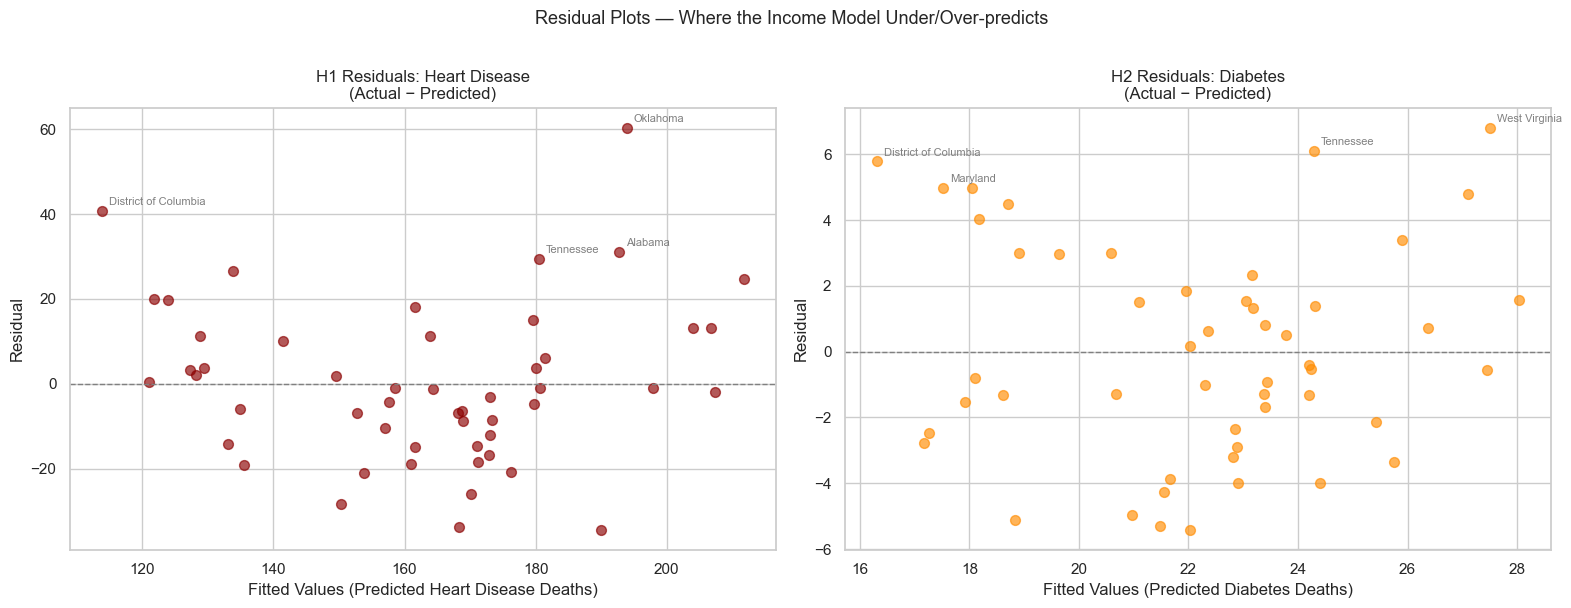

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# H1 residuals
eda_df['H1_predicted'] = hyp1_model.fittedvalues
eda_df['H1_residual']  = hyp1_model.resid

axes[0].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[0].scatter(eda_df['H1_predicted'], eda_df['H1_residual'],
                color='darkred', alpha=0.65, s=50)

# Label top outliers by absolute residual
for _, row in eda_df.nlargest(4, 'H1_residual').iterrows():
    axes[0].annotate(row['State'],
                     (row['H1_predicted'], row['H1_residual']),
                     textcoords='offset points', xytext=(5, 4),
                     fontsize=8, color='gray')

axes[0].set_title("H1 Residuals: Heart Disease\n(Actual − Predicted)", fontsize=12)
axes[0].set_xlabel("Fitted Values (Predicted Heart Disease Deaths)")
axes[0].set_ylabel("Residual")

# H2 residuals
eda_df['H2_predicted'] = hyp2_model.fittedvalues
eda_df['H2_residual']  = hyp2_model.resid

axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].scatter(eda_df['H2_predicted'], eda_df['H2_residual'],
                color='darkorange', alpha=0.65, s=50)

for _, row in eda_df.nlargest(4, 'H2_residual').iterrows():
    axes[1].annotate(row['State'],
                     (row['H2_predicted'], row['H2_residual']),
                     textcoords='offset points', xytext=(5, 4),
                     fontsize=8, color='gray')

axes[1].set_title("H2 Residuals: Diabetes\n(Actual − Predicted)", fontsize=12)
axes[1].set_xlabel("Fitted Values (Predicted Diabetes Deaths)")
axes[1].set_ylabel("Residual")

plt.suptitle("Residual Plots — Where the Income Model Under/Over-predicts",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
- Most states cluster near residual = 0, confirming good overall model fit.
- **H1:** Oklahoma (+60), Mississippi (+25), Alabama (+21) are the most underpredicted — 
  their actual heart disease mortality is much worse than income alone predicts. These states 
  share structural disadvantages (rural care access, diet, chronic stress) not captured by income.
- **H2:** West Virginia (+10) is the dominant outlier — its diabetes mortality far exceeds 
  what its income level would predict, consistent with documented opioid-linked metabolic health crises.
- States with large **negative** residuals (better than predicted) include Alaska and Hawaii — 
  both have higher-than-average incomes but also unique demographic and geographic factors.
- These systematic patterns in the residuals are exactly why Hypothesis 4 adds behavioral controls: 
  to capture what pure income cannot explain.

### Residual Analysis for Hypothesis 3

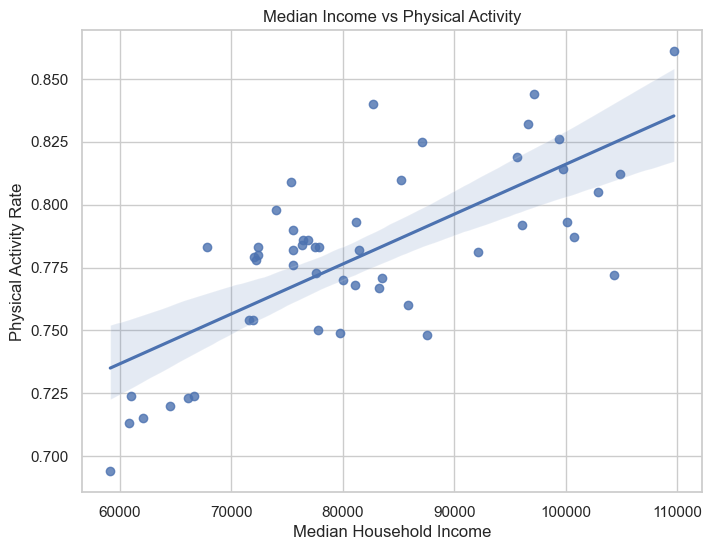

In [17]:
plt.figure(figsize=(8,6))
sns.regplot(x='Median_Income', y='Physical_Activity', data=eda_df)

plt.title('Median Income vs Physical Activity')
plt.xlabel('Median Household Income')
plt.ylabel('Physical Activity Rate')
plt.show()

**Interpretation:**

The scatter plot shows a clear positive relationship between median household income and physical activity levels. States with higher income tend to exhibit higher proportions of adults meeting physical activity guidelines.

The upward-sloping regression line indicates a consistent positive association across income levels, with most states clustered relatively close to the fitted line. This suggests that income is a strong predictor of physical activity at the state level.

While there is some variation around the trend line, no major nonlinear pattern is observed, supporting the use of a linear model. Overall, the visual evidence aligns with the regression results and reinforces the conclusion that higher-income states tend to have higher physical activity participation.

*** 
## Conclusion

- We find strong evidence of a **socioeconomic gradient in health outcomes**, where higher-income states consistently exhibit lower rates of heart disease and diabetes mortality  

- The negative relationship between income and mortality remains **statistically significant even after controlling for behavioral factors**, indicating that income has an independent effect on health outcomes  

- Behavioral variables such as **smoking, obesity, and physical activity** are also significant predictors of mortality, suggesting that part of the income effect operates through health-related behaviors  

- However, the persistence of the income coefficient after including controls indicates that **income influences health both directly and indirectly**  

- Geographic analysis further shows that **low-income, high-mortality states are regionally clustered**, particularly in the Southern United States, highlighting broader structural and environmental factors  

- Overall, our findings suggest that improving health outcomes requires not only targeting individual behaviors but also addressing **underlying socioeconomic disparities**

---
## Limitations

**1. Small sample size (n = 51).** Our analysis is restricted to 51 state-level observations. This limits statistical power, makes regression coefficients sensitive to outliers, and prevents us from studying within-state variation (e.g., rural vs. urban differences). The TA noted that ZIP-code level data would enable a more fine-grained analysis; we were unable to find 2024 data at that resolution for all variables, so state-level analysis is our approach.

**2. Cross-sectional design.** Because we use a single year (2024), we cannot make causal claims about the direction of the income–health relationship. States with historically poor health outcomes may attract less investment and have lower incomes as a result (reverse causality), or both may be driven by a third factor (omitted variable bias).

**3. Mean imputation for Tennessee missing values.** Tennessee's values for `Diabetes_Prevalence`, `Poor_Health`, `Physical_Activity`, `Smoking`, and `Obesity` were suppressed in the KFF source data (small BRFSS survey sample). We imputed these five cells with column means to preserve Tennessee as an observation. Tennessee's imputed behavioral values may not accurately reflect its true profile — this is particularly relevant for analyses involving smoking or obesity.

**4. Missing socioeconomic controls.** Education, employment, and poverty datasets were initially explored but were incompatible with state-level aggregation. Including education attainment or poverty rates as additional controls could improve the regression models and reduce omitted variable bias.

**5. Ecological fallacy.** All variables are state-level aggregates. Relationships observed at the state level may not hold at the individual level (e.g., not every low-income individual in a low-income state has poor health outcomes). Our conclusions apply to states as units, not individuals.

**6. Multicollinearity.** Income, smoking, and obesity are strongly correlated with each other (r > 0.80). This makes it difficult to isolate the independent contribution of each variable in regression models, and may inflate standard errors on the behavioral covariates.

***
## Acknowledgements and Bibliography

- U.S. Census Bureau. *American Community Survey (ACS) 2024 1-Year Estimates.*  

  https://www.census.gov/programs-surveys/acs  

- Kaiser Family Foundation (KFF). *State Health Facts (2024).*  

  https://www.kff.org/statedata/  

- Statsmodels Developers. *Statsmodels: Statistical Modeling in Python.*  

  https://www.statsmodels.org/  

- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment.* Computing in Science & Engineering, 9(3), 90–95.  

- Waskom, M. (2021). *Seaborn: Statistical Data Visualization.* Journal of Open Source Software.  

- Plotly Technologies Inc. *Plotly: Interactive Data Visualization Library.*  

  https://plotly.com/python/  

- Project GitHub Repository:  

  https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project  